<a href="https://colab.research.google.com/github/thisisaadi123/stock-forecasting-using-chronos/blob/main/Stock_forecasting_using_chronos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

!pip install -q triton accelerate torchao
!pip install -q git+https://github.com/amazon-science/chronos-forecasting.git

print("Dependencies installed successfully.")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 79.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 32.7 MB/s eta 0:00:00
Dependencies installed successfully.


In [4]:
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
from chronos import BaseChronosPipeline

pipeline = BaseChronosPipeline.from_pretrained(
    "amazon/chronos-bolt-small",
    device_map="cuda" if torch.cuda.is_available() else "cpu",
    torch_dtype=torch.bfloat16,
)

print(f"Model loaded on: {pipeline.model.device}")

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/191M [00:00<?, ?B/s]

Model loaded on: cuda:0


In [5]:

df = pd.read_csv('SPY.csv')
target_columns = ['close', 'volume']
context_data = df[target_columns].values[-512:].T
context_tensor = torch.tensor(context_data)

print(f"Multivariate Context Tensor Shape: {context_tensor.shape}")

Multivariate Context Tensor Shape: torch.Size([2, 512])


In [8]:
prediction_length = 30
quantiles_tensor, mean_tensor = pipeline.predict_quantiles(
    context_tensor,
    prediction_length=prediction_length,
    quantile_levels=[0.1, 0.5, 0.9]
)
quantiles_np = quantiles_tensor.cpu().numpy()
close_quantiles = quantiles_np[0]
low_bound = close_quantiles[:, 0]
median_forecast = close_quantiles[:, 1]
high_bound = close_quantiles[:, 2]

print("Multivariate quantile forecast generated successfully.")

Multivariate quantile forecast generated successfully.


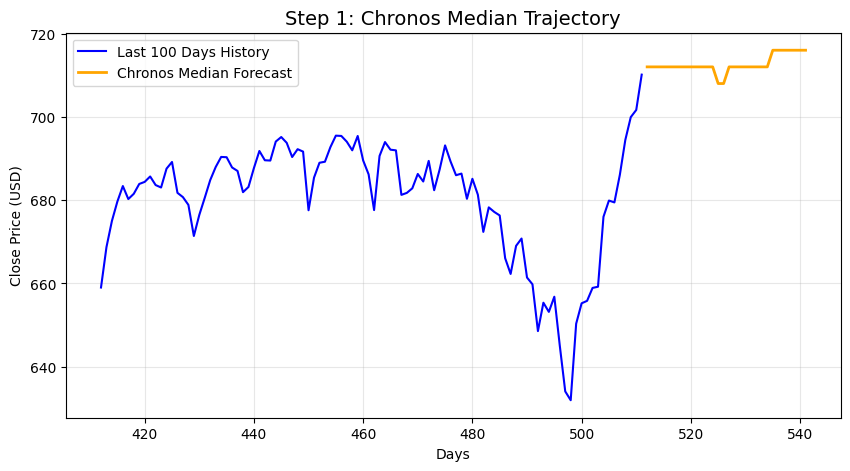

In [11]:

context_close = context_tensor[0].numpy()
median_forecast_close = quantiles_np[0, :, 1]

historical_days = np.arange(len(context_close))
future_days = np.arange(len(context_close), len(context_close) + prediction_length)

plt.figure(figsize=(10, 5), facecolor='white')
plt.plot(historical_days[-100:], context_close[-100:], color='blue', label='Last 100 Days History')
plt.plot(future_days, median_forecast_close, color='orange', linewidth=2, label='Chronos Median Forecast')

plt.title('Step 1: Chronos Median Trajectory', fontsize=14)
plt.xlabel('Days')
plt.ylabel('Close Price (USD)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

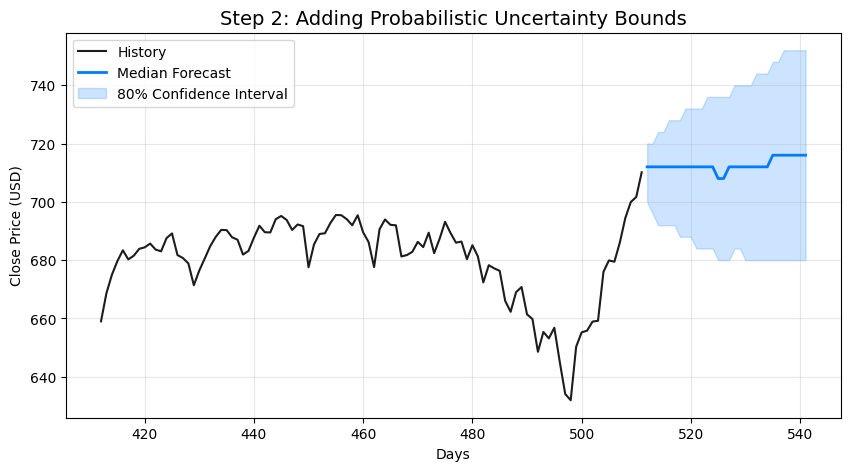

In [12]:

low_bound_close = quantiles_np[0, :, 0]   # 10th percentile
high_bound_close = quantiles_np[0, :, 2]  # 90th percentile

# Plot 2: Adding Uncertainty
plt.figure(figsize=(10, 5), facecolor='white')
plt.plot(historical_days[-100:], context_close[-100:], color='#1c1c1e', label='History')
plt.plot(future_days, median_forecast_close, color='#007aff', linewidth=2, label='Median Forecast')

# Shading the probability region
plt.fill_between(future_days, low_bound_close, high_bound_close, color='#007aff', alpha=0.2, label='80% Confidence Interval')

plt.title('Step 2: Adding Probabilistic Uncertainty Bounds', fontsize=14)
plt.xlabel('Days')
plt.ylabel('Close Price (USD)')
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.show()

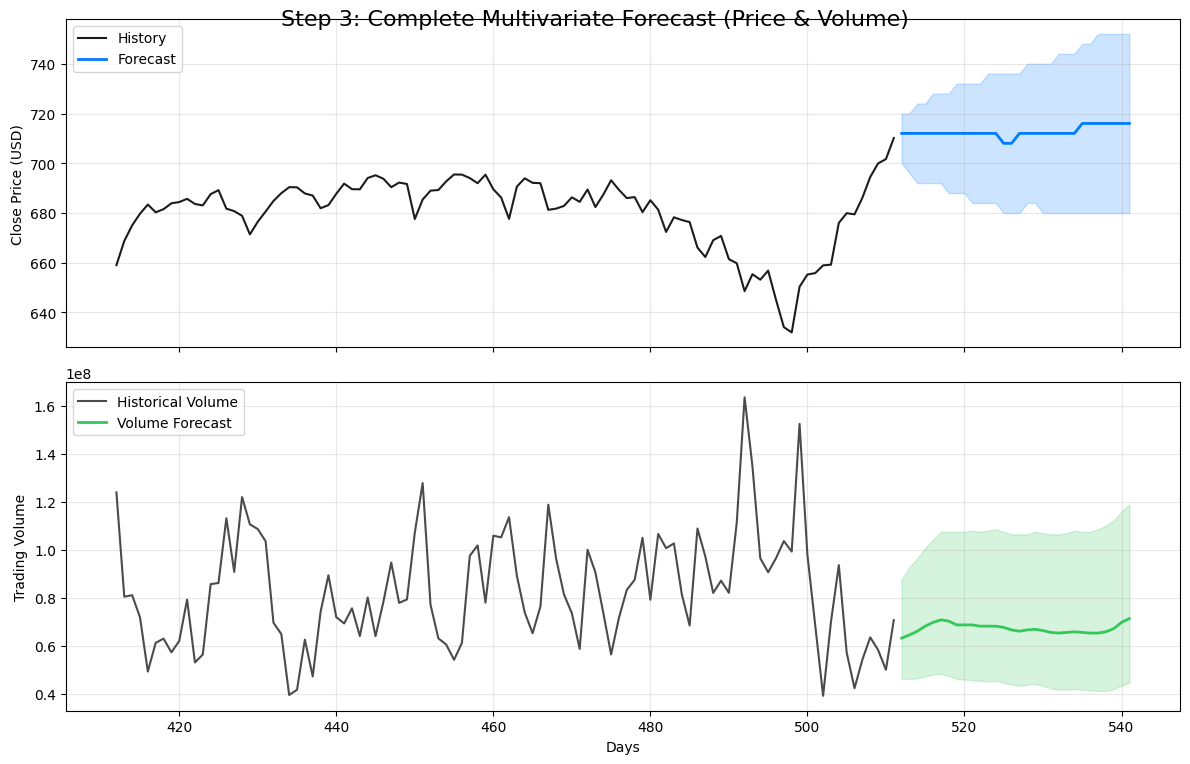

In [13]:
# Extracting the Volume data (Index 1 of our tensor/quantiles)
context_vol = context_tensor[1].numpy()
median_vol = quantiles_np[1, :, 1]
low_vol = quantiles_np[1, :, 0]
high_vol = quantiles_np[1, :, 2]

# Plot 3: Dual-Axis Multivariate Dashboard
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, facecolor='white')
fig.suptitle('Step 3: Complete Multivariate Forecast (Price & Volume)', fontsize=16, y=0.95)

# --- TOP GRAPH: Close Price ---
ax1.plot(historical_days[-100:], context_close[-100:], color='#1c1c1e', label='History')
ax1.plot(future_days, median_forecast_close, color='#007aff', linewidth=2, label='Forecast')
ax1.fill_between(future_days, low_bound_close, high_bound_close, color='#007aff', alpha=0.2)
ax1.set_ylabel('Close Price (USD)')
ax1.legend(loc='upper left')
ax1.grid(alpha=0.3)

# --- BOTTOM GRAPH: Trading Volume ---
ax2.plot(historical_days[-100:], context_vol[-100:], color='#4b4b4d', label='Historical Volume')
ax2.plot(future_days, median_vol, color='#34c759', linewidth=2, label='Volume Forecast')
ax2.fill_between(future_days, low_vol, high_vol, color='#34c759', alpha=0.2)
ax2.set_ylabel('Trading Volume')
ax2.set_xlabel('Days')
ax2.legend(loc='upper left')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

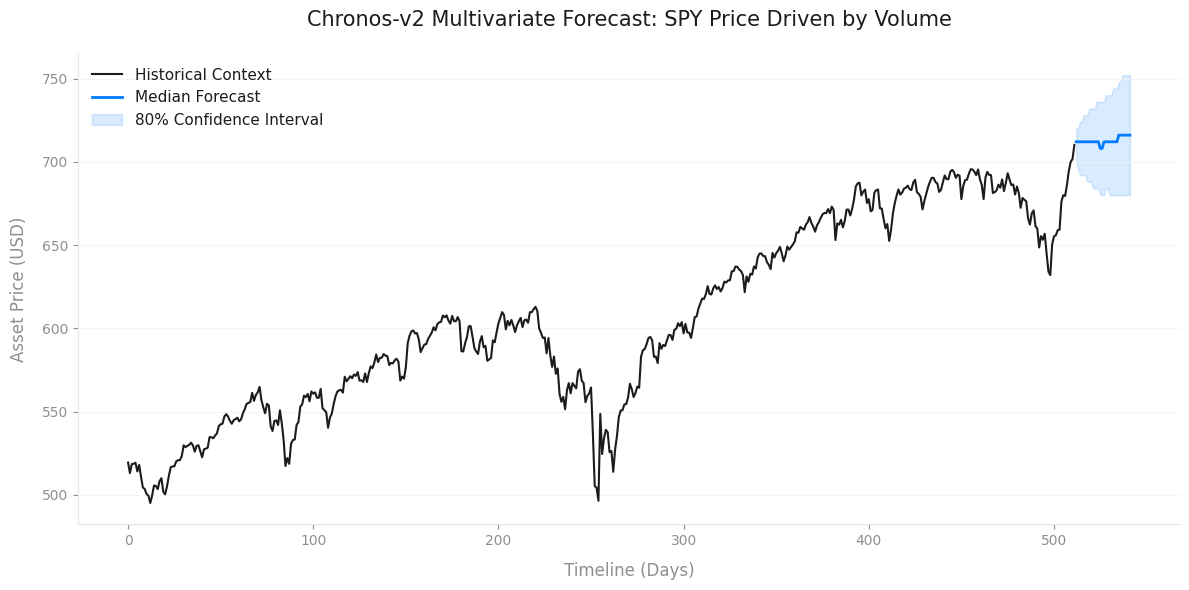

In [14]:
# Set up the timeline axes
context_close = context_tensor[0].numpy() # Extract just the close data for plotting
historical_days = np.arange(len(context_close))
future_days = np.arange(len(context_close), len(context_close) + prediction_length)

# Aesthetic UI Configuration
plt.figure(figsize=(12, 6), facecolor='#ffffff')
ax = plt.gca()
ax.set_facecolor('#ffffff')

# Remove top and right spines for a cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#e5e5ea')
ax.spines['bottom'].set_color('#e5e5ea')

# Subtle grid lines
plt.grid(axis='y', linestyle='-', color='#f2f2f7', alpha=0.8)

# Plot Historical Context (Sleek dark grey)
plt.plot(historical_days, context_close, color='#1c1c1e', label='Historical Context', linewidth=1.5)

# Plot Median Forecast (Vibrant blue)
plt.plot(future_days, median_forecast, color='#007aff', label='Median Forecast', linewidth=2)

# Fill Confidence Interval (Transparent blue)
plt.fill_between(
    future_days,
    low_bound,
    high_bound,
    color='#007aff',
    alpha=0.15,
    label='80% Confidence Interval'
)

# Typography and Labels
plt.title('Chronos-v2 Multivariate Forecast: SPY Price Driven by Volume', fontsize=15, fontweight='500', color='#1c1c1e', pad=20)
plt.xlabel('Timeline (Days)', fontsize=12, color='#8e8e93', labelpad=10)
plt.ylabel('Asset Price (USD)', fontsize=12, color='#8e8e93', labelpad=10)
plt.tick_params(axis='both', colors='#8e8e93', labelsize=10)

# Minimalist Legend
plt.legend(frameon=False, loc='upper left', fontsize=11, labelcolor='#1c1c1e')

plt.tight_layout()
plt.show()